# Fake News Detection — Data Cleaning & Preprocessing

**CST-3121 Group Project** | Data & Preprocessing Lead deliverable

This notebook loads the raw dataset, performs EDA, cleans text, and creates train/validation/test splits.

## 1. Setup

In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path(__file__).parent.resolve()
DATA_PATH = PROJECT_ROOT / "data" / "news.csv"
OUTPUT_DIR = PROJECT_ROOT / "Output"
FIGURES_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path exists: {DATA_PATH.exists()}")

Project root: /Users/mini/Documents
Data path exists: True


## 2. Load Raw Data

In [3]:
df_raw =pd.read_csv(DATA_PATH, index_col=0)
df_raw.index.name = "article_id"
df_raw = df_raw.reset_index()

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (6335, 4)


,article_id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


## 3. Data Quality Checks

In [4]:
def count_pattern(series, pattern):
    return series.fillna("").str.contains(pattern, regex=True, case=False).sum()

quality = {
    "empty_title": (df_raw["title"].fillna("").str.strip() == "").sum(),
    "empty_text": (df_raw["text"].fillna("").str.strip() == "").sum(),
    "short_text_le_20": (df_raw["text"].fillna("").str.strip().str.len() <= 20).sum(),
    "duplicate_title_text": df_raw.duplicated(subset=["title", "text"]).sum(),
    "rows_with_urls": count_pattern(df_raw["title"] + " " + df_raw["text"], r"https?://|www\."),
    "rows_with_html": count_pattern(df_raw["title"] + " " + df_raw["text"], r"<[^>]+>"),
}

pd.Series(quality, name="count")

empty_title               0
empty_text               36
short_text_le_20         39
duplicate_title_text     29
rows_with_urls          378
rows_with_html           29
Name: count, dtype: int64

## 4. Cleaning Functions

In [5]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

## 5. Apply Cleaning

In [6]:
df = df_raw.copy()
rows_before = len(df)

# Clean text fields
df["title_clean"] = df["title"].apply(clean_text)
df["text_clean"] = df["text"].apply(clean_text)
df["full_text"] = (df["title_clean"] + " " + df["text_clean"]).str.strip()

# Drop invalid rows
df = df[df["label"].notna()]
df = df[df["title_clean"].str.len() > 0]
df = df[df["text_clean"].str.len() > 20]

# Drop exact duplicates on original title+text
df = df.drop_duplicates(subset=["title", "text"], keep="first")

# Numeric labels
df["label_num"] = df["label"].map({"REAL": 0, "FAKE": 1})

rows_after = len(df)
print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning:  {rows_after}")
print(f"Rows removed:         {rows_before - rows_after}")
print("\nLabel distribution after cleaning:")
print(df["label"].value_counts())

Rows before cleaning: 6335
Rows after cleaning:  6267
Rows removed:         68

Label distribution after cleaning:
label
REAL    3154
FAKE    3113
Name: count, dtype: int64


## 6. Before / After Examples

In [7]:
examples = df_raw[
    df_raw["text"].fillna("").str.contains(r"http\S+|www\.\S+", regex=True, case=False)
].head(2)

for _, row in examples.iterrows():
    print("=" * 80)
    print("TITLE:", row["title"][:100])
    print("\nBEFORE (first 300 chars):")
    print(str(row["text"])[:300])
    print("\nAFTER (first 300 chars):")
    print(clean_text(row["text"])[:300])

TITLE: Watch The Exact Moment Paul Ryan Committed Political Suicide At A Trump Rally (VIDEO)

BEFORE (first 300 chars):
Google Pinterest Digg Linkedin Reddit Stumbleupon Print Delicious Pocket Tumblr 
There are two fundamental truths in this world: Paul Ryan desperately wants to be president. And Paul Ryan will never be president. Today proved it. 
In a particularly staggering example of political cowardice, Paul Rya

AFTER (first 300 chars):
Google Pinterest Digg Linkedin Reddit Stumbleupon Print Delicious Pocket Tumblr There are two fundamental truths in this world: Paul Ryan desperately wants to be president. And Paul Ryan will never be president. Today proved it. In a particularly staggering example of political cowardice, Paul Ryan 
TITLE: Bernie supporters on Twitter erupt in anger against the DNC: 'We tried to warn you!'

BEFORE (first 300 chars):
— Kaydee King (@KaydeeKing) November 9, 2016 The lesson from tonight's Dem losses: Time for Democrats to start listening to the voter

## 7. Save Cleaned Data

In [8]:
output_cols = [
    "article_id", "title_clean", "text_clean",
    "full_text", "label", "label_num",
]

df_clean = df[output_cols].copy()
clean_path = OUTPUT_DIR / "news_clean.csv"
df_clean.to_csv(clean_path, index=False)

print(f"Saved cleaned data to: {clean_path}")
print(f"Shape: {df_clean.shape}")
df_clean.head()

Saved cleaned data to: /Users/mini/Documents/AI_Project/Output/news_clean.csv
Shape: (6267, 6)


,article_id,title_clean,text_clean,full_text,label,label_num
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",You Can Smell Hillary’s Fear Daniel Greenfield...,FAKE,1
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE,1
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,Kerry to go to Paris in gesture of sympathy U....,REAL,0
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",Bernie supporters on Twitter erupt in anger ag...,FAKE,1
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,The Battle of New York: Why This Primary Matte...,REAL,0


### 8.EDA

In [9]:
print(df_clean.info())
print("\nLabel distribution:")
print(df_clean["label"].value_counts())
print("\nMissing values:")
print(df_clean.isnull().sum())

<class 'pandas.DataFrame'>
Index: 6267 entries, 0 to 6334
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   article_id   6267 non-null   int64
 1   title_clean  6267 non-null   str  
 2   text_clean   6267 non-null   str  
 3   full_text    6267 non-null   str  
 4   label        6267 non-null   str  
 5   label_num    6267 non-null   int64
dtypes: int64(2), str(4)
memory usage: 342.7 KB
None

Label distribution:
label
REAL    3154
FAKE    3113
Name: count, dtype: int64

Missing values:
article_id     0
title_clean    0
text_clean     0
full_text      0
label          0
label_num      0
dtype: int64


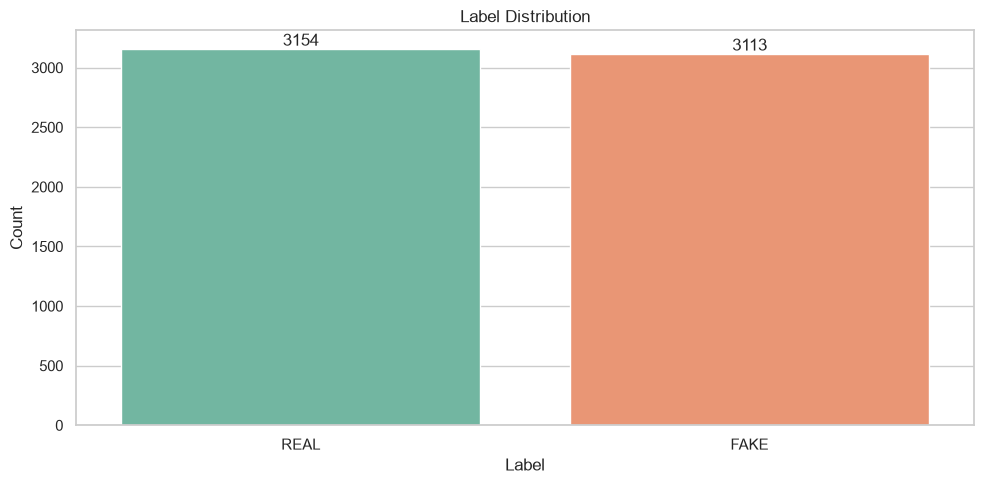

In [10]:
label_counts =df_clean["label"].value_counts()

fig, ax = plt.subplots()
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="Set2", legend=False, ax=ax)
ax.set_title("Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 30, str(v), ha="center")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "label_distribution.png", dpi=150)
plt.show()

In [11]:
df_clean["title_len"] = df_clean["title_clean"].fillna("").str.len()
df_clean["text_len"] = df_clean["text_clean"].fillna("").str.len()
df_clean["combined_len"] = (df_clean["title_clean"].fillna("") + " " + df_clean["text_clean"].fillna("")).str.len()

length_summary = df_clean[["title_len", "text_len", "combined_len"]].describe()
print(length_summary)

         title_len       text_len   combined_len
count  6267.000000    6267.000000    6267.000000
mean     65.243179    4711.111377    4777.354556
std      23.726832    5080.383755    5081.036149
min       1.000000      28.000000      47.000000
25%      49.000000    1756.500000    1829.000000
50%      64.000000    3645.000000    3718.000000
75%      78.000000    6184.500000    6247.500000
max     289.000000  114890.000000  114966.000000


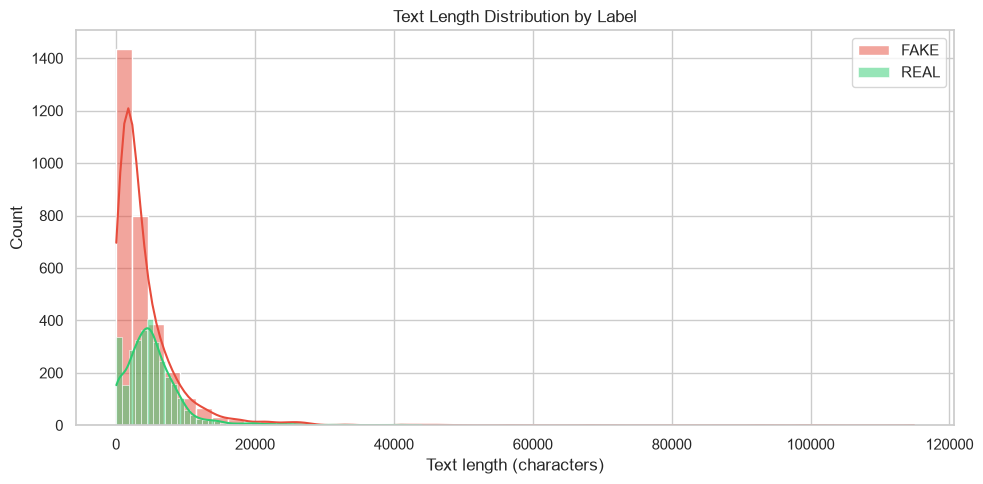

In [12]:
fig, ax = plt.subplots()
for label, color in [("FAKE", "#e74c3c"), ("REAL", "#2ecc71")]:
    subset = df_clean[df_clean["label"] == label]["text_len"]
    sns.histplot(subset, bins=50, kde=True, label=label, color=color, alpha=0.5, ax=ax)
ax.set_title("Text Length Distribution by Label")
ax.set_xlabel("Text length (characters)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_length_distribution.png", dpi=150)
plt.show()

In [13]:
for label in ["FAKE", "REAL"]:
    print(f"\n=== Sample {label} articles ===")
    display(df_clean[df_clean["label"] == label][["article_id", "title_clean", "text_clean"]].head(2))


=== Sample FAKE articles ===


,article_id,title_clean,text_clean
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello..."
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...



=== Sample REAL articles ===


,article_id,title_clean,text_clean
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...


## 9. Train / Validation / Test Split

In [14]:
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label_num"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_num"],
    random_state=42,
)

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    path = OUTPUT_DIR / f"{name}.csv"
    split_df.to_csv(path, index=False)
    print(f"{name:5s}: {len(split_df):5d} rows | FAKE={ (split_df['label_num']==1).sum() } REAL={ (split_df['label_num']==0).sum() } -> {path}")

train:  4386 rows | FAKE=2179 REAL=2207 -> /Users/mini/Documents/AI_Project/Output/train.csv
val  :   940 rows | FAKE=467 REAL=473 -> /Users/mini/Documents/AI_Project/Output/val.csv
test :   941 rows | FAKE=467 REAL=474 -> /Users/mini/Documents/AI_Project/Output/test.csv


## 10. Summary

- Loaded raw `news.csv` and performed EDA
- Removed empty/short text rows and exact duplicates
- Normalized whitespace, URLs, and HTML tags
- Created `full_text` feature (title + body)
- Saved `outputs/news_clean.csv` and stratified train/val/test splits

**Next step:** Run `notebooks/02_baseline_models.ipynb` to train Logistic Regression and Random Forest baselines.